# In-silico gene perturbation with `ov.single.perturb`

**`ov.single.perturb`** runs a *virtual* gene perturbation on a single
`AnnData` and returns:

- the **post-perturbation expression** estimate,
- the **post-perturbation gene regulatory network** (`networkx.DiGraph`),
- a **per-edge Δ-table** showing which TF → target edges changed, and
- a **per-gene Δ-expression table** with the top affected downstream
  genes.

Three modes are supported via the same call:

| `mode=` | Meaning | Effect on the target gene |
|---|---|---|
| `'ko'` | Knockout | expression clamped to 0 |
| `'kd'` | Knockdown | expression scaled by `1 / fold_change` |
| `'oe'` | Over-expression | expression scaled by `fold_change` |

Two backends ship in Phase 1:

| Backend | Min data | Key idea | KO | KD | OE | GRN out |
|---|---|---|---|---|---|---|
| `'sctenifoldknk'` ⭐ | **scRNA only** | Builds a PCNet from raw counts, virtually KOs the gene's row/column, returns the differential network | ✅ | ✅ | ✅ | ✅ |
| `'cell_oracle'` | scRNA + base GRN | Propagates the perturbation through a base GRN (motif/ATAC) for `n_propagation` steps; emits trajectory shift + a perturbed GRN | ✅ | ✅ | ✅ | ✅ |
| `'auto'` (default) | — | picks `cell_oracle` if `adata.uns['base_grn']` is present, otherwise falls back to `sctenifoldknk` | | | | |

Both backends are **lazy imports** — `omicverse.single` imports cleanly
even when neither is installed; the `ImportError` only fires when the
user actually calls `perturb`.

In this tutorial we use the **scRNA-only `sctenifoldknk` backend** on
the mouse hematopoiesis dataset
[Nestorowa *et al.* 2016](https://doi.org/10.1182/blood-2016-05-716480)
to virtually knock out a key TF and reconstruct the downstream GRN.

> **Install:** `pip install sctenifoldpy` (the PyPI name; the import is
> `import scTenifold`). For CellOracle: `pip install celloracle`.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the dataset

We reuse the **mouse hematopoiesis** AnnData from
[Nestorowa *et al.* 2016](https://doi.org/10.1182/blood-2016-05-716480)
that the SCENIC tutorial uses — a great fit for in-silico knockout
because hematopoietic TFs (`Gata1`, `Spi1`, `Gata2`, `Klf1`, `Cebpa`)
are well-characterised, so we can sanity-check the predicted
downstream genes against the literature.

In [2]:
adata = ov.single.mouse_hsc_nestorowa16()
print('shape:', adata.shape)
print('cell types:', adata.obs['cell_type_roughly'].unique())

Load mouse_hsc_nestorowa16_v0.h5ad


  0%|          | 0.00/134M [00:00<?, ?B/s]

shape: (1645, 3000)
cell types: ['MPP', 'HSC', 'LMPP', 'GMP', 'CMP', 'MEP']
Categories (6, object): ['CMP', 'GMP', 'HSC', 'LMPP', 'MEP', 'MPP']


The dataset is dense for a 10-year-old study (~2.7k cells × ~3.9k
genes). For a faster, more focused demo we keep the top variable genes
and ensure key hematopoietic TFs are kept regardless of variance.

> If your gene set is larger than ~1k, scTenifoldKnk will run for tens
> of minutes. For tutorial speed we cap at 600 genes; full production
> runs should keep the full HVG set.

In [3]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=600,
                            subset=False, layer=None)
must_keep = ['Gata1', 'Spi1', 'Klf1', 'Gata2', 'Cebpa', 'Tal1',
             'Mpo', 'Hbb-bt', 'Hbb-bs', 'Hba-a1', 'Elane', 'Ctsg', 'Prtn3']
keep_mask = adata.var['highly_variable'].copy()
for g in must_keep:
    if g in adata.var_names:
        keep_mask[g] = True
adata_sub = adata[:, keep_mask].copy()
print('subset shape:', adata_sub.shape)
print('canonical hematopoietic TFs present:',
      [g for g in must_keep if g in adata_sub.var_names])

subset shape: (1645, 601)
canonical hematopoietic TFs present: ['Gata1', 'Klf1', 'Gata2', 'Mpo', 'Hbb-bt', 'Elane', 'Ctsg', 'Prtn3']


## 2. Quick API tour

`ov.single.perturb` is one call. Below is the minimal three-line
workflow against the `sctenifoldknk` backend.

In [4]:
help(ov.single.perturb)

Help on function perturb in module omicverse.single._perturb:

perturb(adata, target: 'str | Sequence[str]', *, mode: 'str' = 'ko', backend: 'str' = 'auto', fold_change: 'float' = 2.0, grn_base=None, grn_output: 'bool' = True, return_delta: 'bool' = True, layer: 'str | None' = None, n_propagation: 'int' = 3, backend_kwargs: 'dict | None' = None, copy: 'bool' = False)
    In-silico gene perturbation with downstream GRN reconstruction.
    
    Parameters
    ----------
    adata : AnnData
        Cells × genes AnnData. For ``backend='sctenifoldknk'`` raw scRNA
        counts are sufficient; for ``backend='cell_oracle'`` a base GRN
        is required (passed via ``grn_base``, looked up from
        ``adata.uns['base_grn']``, or auto-loaded from the CellOracle
        prepackaged mm10/hg38 GRN if neither is set).
    target : str or sequence of str
        Gene name(s) to perturb. Multiple targets are perturbed in the
        same simulation.
    mode : {'ko', 'kd', 'oe'}, default ``'ko'

## 3. Knockout `Gata1` — the canonical erythroid master TF

`Gata1` is required for erythroid + megakaryocyte differentiation. KO'ing
it should down-regulate hemoglobin and globin genes (`Hbb-*`, `Hba-*`,
`Klf1`) downstream. Let's run the perturbation and see what the GRN says.

> First call may take ~30-90 s as scTenifoldKnk constructs the PCNet
> (parallel principal-component network).

Removed 7 cells with lib size < 1000
Removed 56 outlier cells from original data
Removed 296 genes expressed in less than 0.05 of data
Removed 13 genes with expression values: average < 0.05 or sum < 25


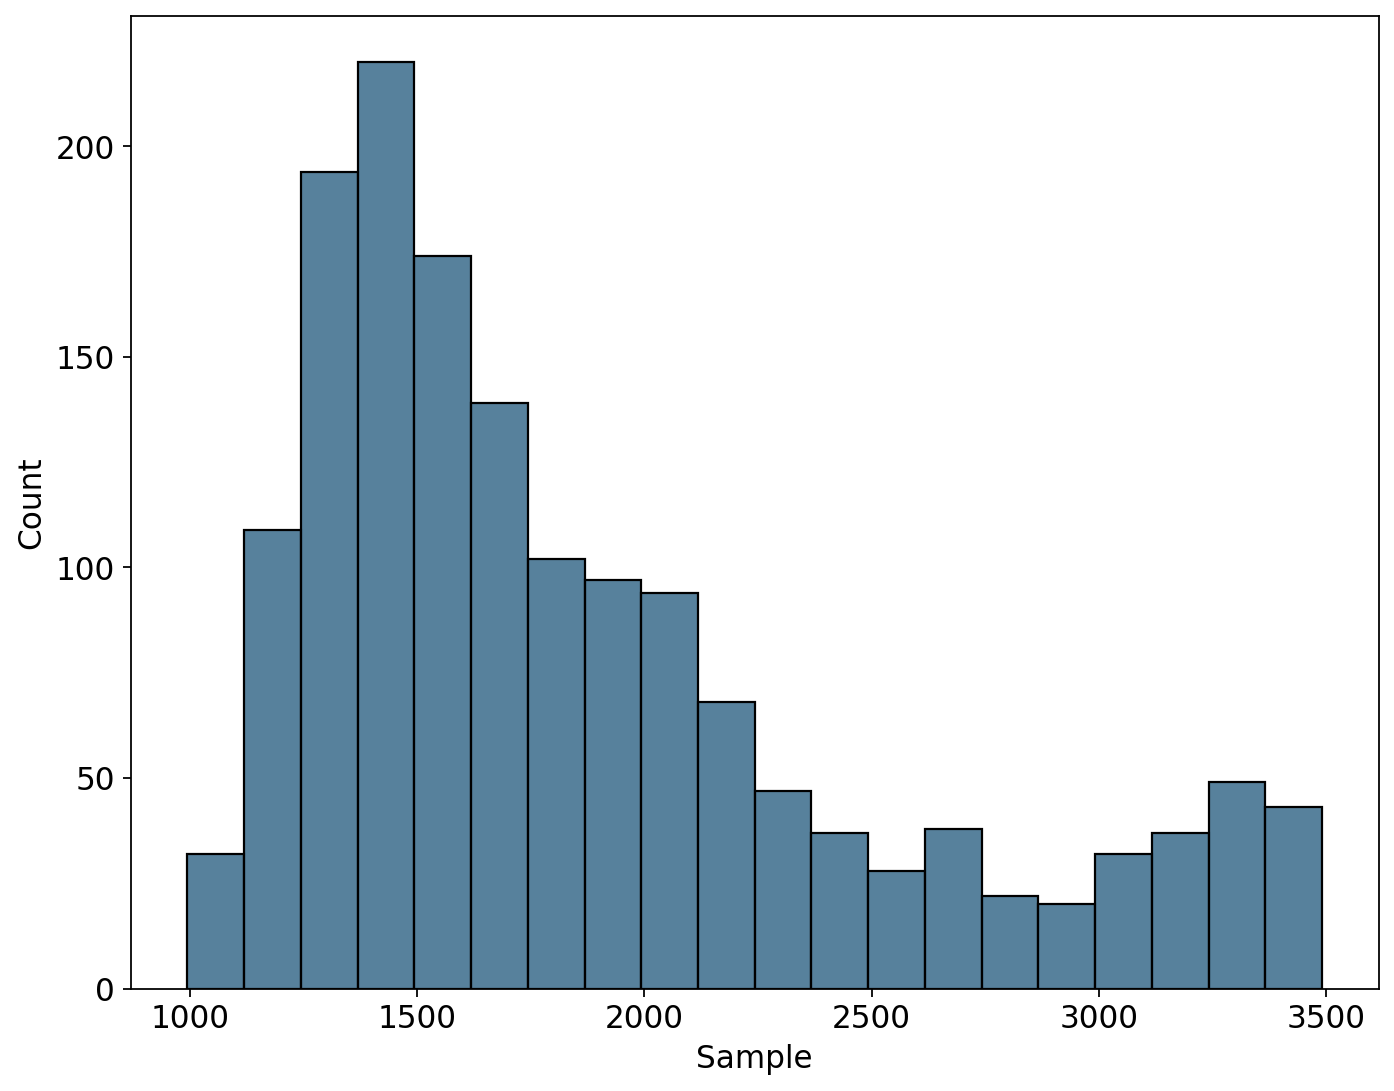

finish QC: WT
process qc finished in 0.1419765860773623 secs.


make_networks  processing time:  15.807986655971035
process nc finished in 15.808271674904972 secs.
Using tensorly


(292, 292, 10)
tensor_decomp  processing time:  0.41664621885865927
process td finished in 0.42210899107158184 secs.
process ko finished in 0.0010597449727356434 secs.
manifold_alignment  processing time:  0.028122473042458296
process ma finished in 0.028176849940791726 secs.
d_regulation  processing time:  0.08593104686588049
process dr finished in 0.08598715905100107 secs.
target: Gata1
mode: ko | backend: sctenifoldknk
|V(GRN_base)| = 292
|E(GRN_base)| = 8317
|V(GRN_perturbed)| = 292
|E(GRN_perturbed)| = 8235
CPU times: user 1min 7s, sys: 2min 57s, total: 4min 4s
Wall time: 16.6 s


In [5]:
%%time
result = ov.single.perturb(
    adata_sub,
    target='Gata1',
    mode='ko',                        # | 'kd' | 'oe'
    backend='sctenifoldknk',
    grn_output=True,
    return_delta=True,
)
print('target:', result.target)
print('mode:', result.mode, '| backend:', result.backend)
print('|V(GRN_base)| =', result.grn_base.number_of_nodes())
print('|E(GRN_base)| =', result.grn_base.number_of_edges())
print('|V(GRN_perturbed)| =', result.grn.number_of_nodes())
print('|E(GRN_perturbed)| =', result.grn.number_of_edges())

### 3.1 Top affected downstream genes

`result.delta_expr` is a per-gene table with `delta` (change in summed
in-edge weight) and `log2_fc` (log2 fold-change of the same). The
`summary()` helper prints + returns the top entries sorted by
|Δ-expression|.

In [6]:
top = result.summary(top_n=15)

[ov.single.perturb] target='Gata1' mode='ko' backend='sctenifoldknk'  — top 15 downstream genes by |Δexpr|:
 gene    delta  boxcox-transformed distance        Z    log2_fc      p-value  adjusted p-value  mean_base  mean_pert
Gata1 0.000048                    -8.947090 1.655190 178.221333 1.185184e-40      3.460739e-38        NaN        NaN
 Car2 0.000033                    -9.244127 1.606147  85.039931 2.924000e-20      4.269041e-18        NaN        NaN
 Nkg7 0.000012                   -10.073581 1.469197  10.433426 1.237550e-03      1.204549e-01        NaN        NaN
  Emb 0.000009                   -10.300845 1.431674   5.822489 1.582254e-02      1.000000e+00        NaN        NaN
 Cpa3 0.000007                   -10.424614 1.411239   4.231298 3.968508e-02      1.000000e+00        NaN        NaN
 Cd53 0.000007                   -10.504441 1.398059   3.441949 6.356068e-02      1.000000e+00        NaN        NaN
 Apoe 0.000004                   -10.996409 1.316830   0.954339 3.286172e

### 3.2 Δ-GRN — which edges changed?

`result.delta_grn` is the long-format edge-weight diff table. After a
KO of `Gata1`, the only edges that change are those incident on
`Gata1` itself (its in-edges and out-edges go to 0). The downstream
genes that lose the most regulatory input are the ones the GRN says
are most regulated *by* `Gata1` in the WT network.

In [7]:
dg = result.delta_grn.copy()
print('total changed edges:', len(dg))
print('edges with target = Gata1 (in-edges):  ', (dg['target']=='Gata1').sum())
print('edges with source = Gata1 (out-edges): ', (dg['source']=='Gata1').sum())
print()
print('Out-edges of Gata1 sorted by |delta| (top 10):')
out = dg[dg['source']=='Gata1'].copy()
out = out.reindex(out['delta'].abs().sort_values(ascending=False).index)
print(out.head(10).to_string(index=False))

total changed edges: 8317
edges with target = Gata1 (in-edges):   86
edges with source = Gata1 (out-edges):  82

Out-edges of Gata1 sorted by |delta| (top 10):
source   target  weight_base  weight_pert  delta
 Gata1     Epor          0.3          0.0   -0.3
 Gata1    Ermap          0.3          0.0   -0.3
 Gata1     Klf1          0.3          0.0   -0.3
 Gata1      Rhd          0.3          0.0   -0.3
 Gata1     Car1          0.3          0.0   -0.3
 Gata1    Smim1          0.3          0.0   -0.3
 Gata1    Blvrb          0.3          0.0   -0.3
 Gata1     Aqp1          0.3          0.0   -0.3
 Gata1 C1qtnf12          0.3          0.0   -0.3
 Gata1    Epdr1          0.2          0.0   -0.2


### 3.3 Visualise the affected downstream GRN

We extract the local subnetwork around `Gata1` from both the WT and
post-KO networks, then draw the WT graph with edge widths proportional
to baseline weight and node colours encoding |Δ-expression| from
`result.delta_expr`.

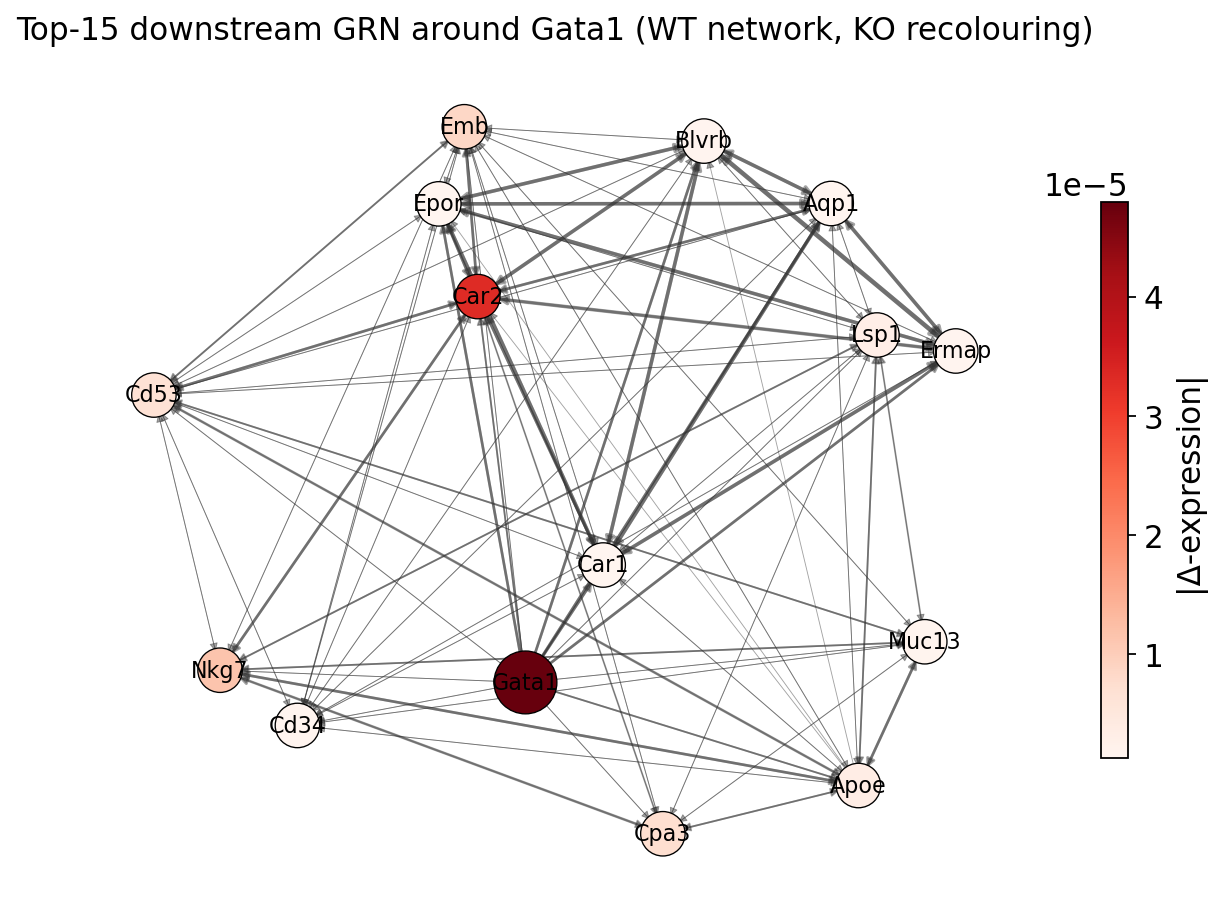

In [8]:
# pick the top-K most affected genes from delta_expr
K = 15
delta_sorted = result.delta_expr.reindex(
    result.delta_expr['delta'].abs().sort_values(ascending=False).index
)
affected = delta_sorted['gene'].head(K).tolist()
local_nodes = ['Gata1'] + [g for g in affected if g != 'Gata1']

g_local = result.grn_base.subgraph(local_nodes).copy()

# Spring layout for a quick-and-clean diagram
pos = nx.spring_layout(g_local, seed=0, k=1.5)
fig, ax = plt.subplots(figsize=(8, 6))

# node colour = |delta| (darker = more affected)
delta_map = dict(zip(result.delta_expr['gene'],
                     np.abs(result.delta_expr['delta'])))
node_colors = [delta_map.get(n, 0) for n in g_local.nodes]
sizes = [800 if n == 'Gata1' else 400 for n in g_local.nodes]

nodes = nx.draw_networkx_nodes(
    g_local, pos, ax=ax, node_color=node_colors,
    node_size=sizes, cmap='Reds', edgecolors='black', linewidths=0.6,
)
nx.draw_networkx_labels(g_local, pos, ax=ax, font_size=10)
weights = [abs(d.get('weight', 1.0)) for _, _, d in g_local.edges(data=True)]
nx.draw_networkx_edges(
    g_local, pos, ax=ax,
    width=[max(0.4, 2.0 * w / max(weights or [1])) for w in weights],
    edge_color='#333', alpha=0.45, arrows=True, arrowsize=8,
)
plt.colorbar(nodes, ax=ax, label='|Δ-expression|', shrink=0.65)
ax.set_title('Top-15 downstream GRN around Gata1 (WT network, KO recolouring)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Over-express vs knockout — comparing two modes

The same call handles `mode='oe'`. Below we over-express `Gata1` at a
3× fold-change and compare the top affected genes against the KO run.

Removed 7 cells with lib size < 1000
Removed 56 outlier cells from original data
Removed 296 genes expressed in less than 0.05 of data
Removed 13 genes with expression values: average < 0.05 or sum < 25


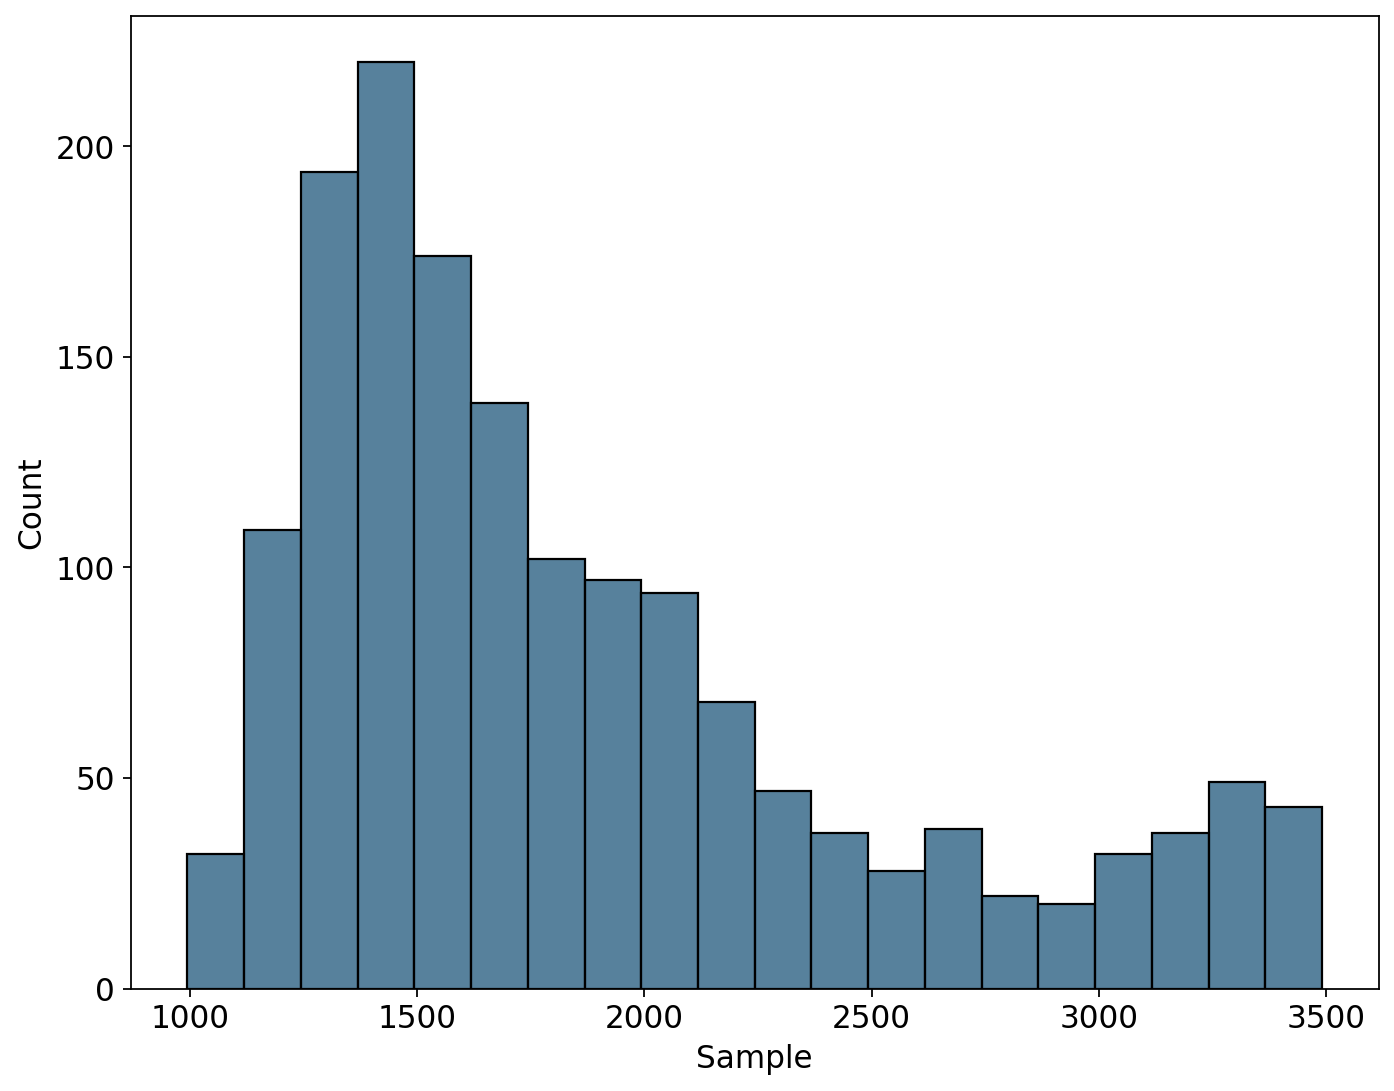

finish QC: WT
process qc finished in 0.1250100100878626 secs.


make_networks  processing time:  16.415950807044283
process nc finished in 16.416424164781347 secs.
Using tensorly


(292, 292, 10)
tensor_decomp  processing time:  0.4328508288599551
process td finished in 0.4378792371135205 secs.
process ko finished in 0.0006794240325689316 secs.
manifold_alignment  processing time:  0.02549557387828827
process ma finished in 0.02554168296046555 secs.
d_regulation  processing time:  0.09435570589266717
process dr finished in 0.09439890692010522 secs.


,gene,delta_ko,log2_fc_ko,delta_oe,log2_fc_oe
0,Gata1,0.000048,178.221333,18.0,1.584962
1,Car2,0.000033,85.039931,NaN,NaN
2,Nkg7,0.000012,10.433426,NaN,NaN
3,Emb,0.000009,5.822489,NaN,NaN
4,Cpa3,0.000007,4.231298,NaN,NaN
5,Cd53,0.000007,3.441949,NaN,NaN
6,Apoe,0.000004,0.954339,NaN,NaN
7,Lsp1,0.000003,0.745605,NaN,NaN
8,Muc13,0.000002,0.233391,NaN,NaN
9,Cd34,0.000002,0.189281,NaN,NaN


In [9]:
result_oe = ov.single.perturb(
    adata_sub,
    target='Gata1',
    mode='oe',
    fold_change=3.0,
    backend='sctenifoldknk',
)

ko_top = result.delta_expr.reindex(
    result.delta_expr['delta'].abs().sort_values(ascending=False).index
).head(10)[['gene', 'delta', 'log2_fc']].rename(columns={
    'delta': 'delta_ko', 'log2_fc': 'log2_fc_ko'
})
oe_top = result_oe.delta_expr.reindex(
    result_oe.delta_expr['delta'].abs().sort_values(ascending=False).index
).head(10)[['gene', 'delta', 'log2_fc']].rename(columns={
    'delta': 'delta_oe', 'log2_fc': 'log2_fc_oe'
})
joined = ko_top.merge(oe_top, on='gene', how='outer')
joined

KO drops the in-edge weights of `Gata1`'s targets toward zero; OE
boosts them. The Δ-expression values are roughly mirror images
(positive for OE, negative for KO) for the genes whose regulation
*depends* on `Gata1`. Genes outside the local neighborhood (no edge
from `Gata1` in the WT network) are unaffected — this is the
GRN-propagation signal that the trajectory-only Dynamo perturbation
cannot give you.

## 5. Side-by-side Δ-expression with `ov.pl.funky_heatmap`

The Δ-expression table is tidy enough to drop straight into the
`ov.pl.funky_heatmap` plotting helper to compare KO vs OE across the
top affected genes.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


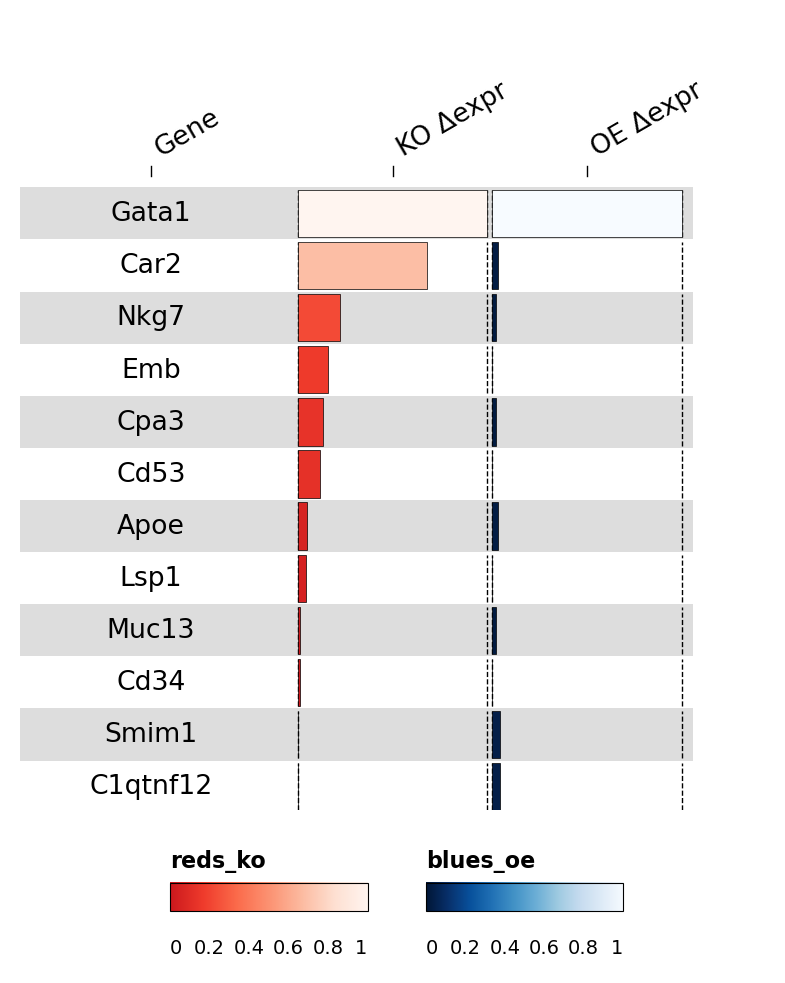

In [10]:
# stack KO + OE deltas for the top 12 genes
top12 = list(joined.head(12)['gene'])
plot_df = pd.DataFrame({
    'id': top12,
    'gene': top12,
    'KO Δ': [result.delta_expr.set_index('gene').loc[g, 'delta']
             if g in result.delta_expr['gene'].values else 0 for g in top12],
    'OE Δ': [result_oe.delta_expr.set_index('gene').loc[g, 'delta']
             if g in result_oe.delta_expr['gene'].values else 0 for g in top12],
})

column_info = pd.DataFrame({
    'id':   ['gene',  'KO Δ',     'OE Δ'],
    'name': ['Gene',  'KO Δexpr', 'OE Δexpr'],
    'geom': ['text',  'bar',      'bar'],
    'palette': [None, 'reds_ko',  'blues_oe'],
})
palettes = {'reds_ko': 'Reds', 'blues_oe': 'Blues'}

fh = ov.pl.funky_heatmap(plot_df, column_info=column_info, palettes=palettes)
fh

## 6. Backend choice — `'auto'` vs explicit

`backend='auto'` (the default) picks `cell_oracle` when a base GRN is
available, otherwise falls back to `sctenifoldknk`. For pure scRNA-seq
this means it always uses the PCNet-based backend — exactly what we
want when no ATAC data is available.

```python
# scRNA-only — picks sctenifoldknk
result = ov.single.perturb(adata, target='Gata1', mode='ko')

# Have a base GRN from ATAC + motif? Pass it via adata.uns['base_grn']
# or via grn_base= — then 'auto' switches to CellOracle.
adata.uns['base_grn'] = motif_df            # DataFrame of TF → target edges
result = ov.single.perturb(adata, target='Gata1', mode='oe',
                            fold_change=2.0, n_propagation=3)
# result.trajectory_shift now contains CellOracle's transition_prob matrix
```

## 7. Summary

| What | Where it lives |
|---|---|
| Function | `ov.single.perturb` |
| Result type | `ov.single.PerturbResult` (dataclass) |
| Per-gene Δ table | `result.delta_expr` (`gene`, `mean_base`, `mean_pert`, `delta`, `log2_fc`) |
| Per-edge Δ table | `result.delta_grn` (`source`, `target`, `weight_base`, `weight_pert`, `delta`) |
| Post-KO/OE GRN | `result.grn` (`networkx.DiGraph`) |
| Baseline GRN | `result.grn_base` (`networkx.DiGraph`) |
| Trajectory shift (CellOracle only) | `result.trajectory_shift` |
| Diagnostic | `result.summary(top_n=N)` — prints + returns top-affected genes |

## References

- Osorio, D., Zhong, Y. *et al.* **scTenifoldKnk: An efficient virtual
  knockout tool for gene function predictions via single-cell gene
  regulatory network perturbation.** *Patterns* 3, 100434 (2022).
- Kamimoto, K., Stringa, B., Hoffmann, C.M. *et al.* **Dissecting cell
  identity via network inference and in silico gene perturbation.**
  *Nature* 614, 742–751 (2023). — CellOracle
- Nestorowa, S., Hamey, F.K., Pijuan Sala, B. *et al.* **A single-cell
  resolution map of mouse hematopoietic stem and progenitor cell
  differentiation.** *Blood* 128, e20–e31 (2016). — the dataset
- Issue [omicverse#739](https://github.com/omicverse/omicverse/issues/739)
  motivated this module.